# Tutorial: spatial counterfactuals on Perturb-FISH with `Cellina` — edge-perturbation variant

Companion to `pfish_analysis.ipynb`: identical preprocessing, training and qualitative-latent
sections (1–3). The only change is in §4. Cellina supports two distinct tissue-graph interventions:
**edge perturbation** (rewire *which* cells are a cell's neighbours, keeping their real expression)
and **node perturbation** (keep the graph fixed, edit neighbours' gene *values*). For this in-vivo
question — what happens to a far T cell if it were surrounded by real perturbed-cancer cells — the
right regime is **edge perturbation**. `pfish_analysis.ipynb`'s §4.2/§4.6 used the node-perturbation
API (`model.get_perturbed_expression`, fed a synthetic mean-KO signature) to fake this; this notebook
uses Cellina's actual edge-rewiring API instead (`model.get_counterfactual_expression` /
`get_counterfactual_latents`, the same calls `scripts/train_loo.py` uses for the CRC/MERFISH LOO
benchmarks).

The scientific question is *perturbation propagation*: CRISPR knockouts sit on **cancer**
cells — do they produce a predictable transcriptional response in **neighbouring T cells**, and can
Cellina reproduce it by literally rewiring a far T cell's spatial neighbours onto real
perturbed-cancer cells?

We start from T cells **far** from any perturbed cancer cell and ask what they would express if their
real spatial neighbours were (real) perturbed-cancer cells, then compare against the real
**near**-perturbed T cells (the ground truth).

**Structure** (mirrors `pfish_analysis.ipynb`): 1. Preprocessing · 2. Training · 3. Qualitative latent
analysis · 4. Counterfactuals via edge-rewiring (effective-KO selection → real/random/mean →
strong-gene robustness → dose-response → strategy comparison) · 5. Interpretation.

Data: `pfish_xenograf_tumor_linearized.h5ad` (154,418 × 154; celltype2 ∈ {cancer, T cells, other};
NF-κB / innate-immune KO panel). Model: reuses the same `cellina_{VARIANT}_pfish/` checkpoint as
`pfish_analysis.ipynb` (only retrains if none is found on disk).


In [1]:
%matplotlib inline
import os, sys, numpy as np, pandas as pd

# Make the notebook runnable regardless of where the Jupyter kernel was launched:
# pfish_prep.py and the .h5ad live in this notebook's directory (…/cellina/InVivo).
for _d in (os.getcwd(), "/g/stegle/schrod/code/cellina/InVivo"):
    if os.path.exists(os.path.join(_d, "pfish_prep.py")):
        os.chdir(_d); sys.path.insert(0, _d); break
else:
    raise FileNotFoundError("pfish_prep.py not found — run from the InVivo directory")

import matplotlib.pyplot as plt
import scanpy as sc
import torch
from scipy.stats import pearsonr, wilcoxon
from scipy.spatial import cKDTree
import pfish_prep as pp
from cellina import Cellina, CellinaGCN

seed = 0
np.random.seed(seed)
VARIANT = 'GAT'
N_LAYERS = 1                                  # GCN depth. N_LAYERS=2 shares pfish_analysis.ipynb's checkpoint;
                                               # any other value gets its own OUT path below (see §4.2 -- testing
                                               # whether hop-2 real-neighbour contamination explains the edge-pert
                                               # correlations requires retraining with N_LAYERS=1, not just capping
                                               # inference-time fanout on the existing 2-layer model).
OUT = f"./cellina_{VARIANT}_pfish" if N_LAYERS == 2 else f"./cellina_{VARIANT}_pfish_L{N_LAYERS}"
H5  = "pfish_xenograf_tumor_linearized.h5ad"

# --- run configuration -------------------------------------------------------
RETRAIN    = False   # if True, retrain even when a saved model exists (see section 2)
MAX_EPOCHS = 100     # training epochs (early stopping on validation loss)
BATCH_SIZE = 256
N_LATENT   = 64
bw, mn     = pp.DEFAULT_BANDWIDTH, pp.DEFAULT_MAX_NEIGHBOURS   # spatial graph geometry (bw=250, mn=30)

# Device: prefer a working GPU, else fall back to CPU. Some nodes expose a GPU whose
# architecture the installed CUDA build does not support ("no kernel image available");
# we probe with a tiny op and drop to CPU if it fails. Set DEVICE = "cpu" to force CPU.
DEVICE = "auto"
def _pick_device(pref):
    if pref == "cpu" or not torch.cuda.is_available():
        return "cpu"
    try:
        _ = (torch.zeros(1, device="cuda") + 1).cpu(); return "cuda"
    except Exception as e:
        print("GPU present but unusable:", str(e).splitlines()[0][:70], "-> using CPU")
        return "cpu"
DEVICE = _pick_device(DEVICE)
print("device:", DEVICE)

EFF9 = ["MAP2K2","IRAK1","IRF7","PELI1","IRF3","IRF5","NFKBIA","LBP","MAP2K3"]  # effective KOs (see 4.1)


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 1. Data preprocessing

The `pfish_prep` module packages the whole pipeline (it must be run identically to
`train_cellina.py` so the graph and held-out set match the trained model):

- **`load_pfish`** — reconstruct integer counts from the linearised `X` (`counts = X · n_counts / 178`)
  and materialise `layers['counts']` (for the NB likelihood) and `layers['lognorm']`.
- **`filter_cells`** — drop ambiguous multi-guide cells (`n_perturb ≥ 2`).
- **`build_graph`** — Gaussian-kernel spatial graph, `w_ij = exp(−d²/2·bw²)`, capped at
  `max_neighbours` (default **bw=250, max_neighbours=30**).
- **`label_context`** — cell context labels (perturbed / control niche).
- **`make_edge_swap_sets`** — the split: `idx_target` = T cells in a perturbed niche (**held out**,
  the ground truth) · `idx_control` = T cells in a *control* niche (the far cells we predict forward).
- **`build_features`** — aggregate neighbour log-norm expression into `obsm['spatial_x']` (masking the
  held-out cells so they can't leak into any niche).


In [2]:
print(f"graph geometry: bandwidth={bw}, max_neighbours={mn}")

adata = pp.load_pfish(H5)
adata = pp.filter_cells(adata, max_n_perturb=1)
adata.obs_names_make_unique()
pp.build_graph(adata, bandwidth=bw, max_neighbours=mn)
pp.label_context(adata)
idx_control, idx_target, donor_idx = pp.make_edge_swap_sets(adata, responder="T cells")
pp.build_features(adata, bandwidth=bw, max_neighbours=mn, test_indices=idx_target)
adata


graph geometry: bandwidth=250.0, max_neighbours=30
[pfish_prep] dropping 307 cells with n_perturb > 1
[pfish_prep] neighbours/cell: median=30 mean=29.4 (bandwidth=250.0, max=30)
[pfish_prep] context counts:
 context
control      120955
perturbed     33156
Name: count, dtype: int64
[pfish_prep] responder='T cells'  control(niche)=14674  target(niche)=22326  donors=93448 (of which perturbed-cancer=6944)


AnnData object with n_obs × n_vars = 154111 × 154
    obs: 'celltype', 'n_perturb', 'perturbation', 'n_counts', 'celltype2', 'context', 'has_pert_neighbour'
    var: 'n_counts'
    uns: 'celltype2_colors', 'log1p', 'pca'
    obsm: 'X_pca', 'spatial', 'spatial_x'
    varm: 'PCs'
    layers: 'log1p', 'counts', 'lognorm'
    obsp: 'spatial_connectivities_orig', 'spatial_connectivities'

### Data splits

The tutorial holds out CRC Myeloid cells; here the held-out set is the **T cells in a perturbed
niche** (`idx_target`). Because they are held out of the reference graph, predicting them is a strict
out-of-distribution task — the model never saw a perturbed niche during training.


In [3]:
obs = adata.obs
print(f"held-out (perturbed-niche) T cells  idx_target : {len(idx_target):>6,}")
print(f"far (control-niche)        T cells  idx_control: {len(idx_control):>6,}")
print("\ncell types:\n", obs["celltype2"].value_counts().to_string())


held-out (perturbed-niche) T cells  idx_target : 22,326
far (control-niche)        T cells  idx_control: 14,674

cell types:
 celltype2
cancer     110658
T cells     39201
other        4252


## 2. Training

**The model.** Cellina is a dual-encoder graph VAE with supervised disentanglement. Each cell gets two
latents: an **intrinsic identity** `z` (encoded from its own expression) and a **spatial niche** `s`
(encoded from the aggregated neighbour features `spatial_x`). A negative-binomial decoder reconstructs
raw counts from both. Two auxiliary heads shape the split:

- **classifier** (`classifier_lambda`) predicts `celltype2` from `z` → forces `z` to carry cell identity;
- **adversary/discriminator** (`discriminator_lambda`) tries to predict the niche `context` from `z`, and
  `z` is trained to *defeat* it → pushes perturbation-context information out of `z` and into `s`.

This is what lets a counterfactual change only the niche (`s` via `spatial_x`) while holding identity
(`z`) fixed.

**Holdout.** The perturbed-niche T cells (`idx_target`) are held out of train/val *and* masked from the
feature reference (§1), so predicting them is strictly out-of-distribution — the model never saw a
perturbed niche.

**Train or load.** The cell below trains only if `RETRAIN=True` **or** no saved model exists at
`{OUT}/model`; otherwise it loads the saved checkpoint. Training is identical to `train_cellina.py`
(≈100 epochs, early stopping on `vae_loss_validation`; a GPU is strongly recommended). If you already
trained a model from `pfish_analysis.ipynb` with the same `VARIANT`, this will just load it.


In [4]:
from scvi.train._callbacks import EarlyStopping, SaveCheckpoint
from sklearn.model_selection import train_test_split

os.makedirs(OUT, exist_ok=True)
need_train = RETRAIN or not os.path.exists(f"{OUT}/model")
print(f"need_train: {need_train}")


need_train: True


In [5]:
from scipy.sparse import issparse, csr_matrix

if not issparse(adata.layers['counts']):
    adata.layers['counts'] = csr_matrix(adata.layers['counts'])
else:
    adata.layers['counts'] = adata.layers['counts'].tocsr()


In [6]:
if need_train:
    why = "RETRAIN=True" if os.path.exists(f"{OUT}/model") else "no saved model found"
    print(f"training Cellina ({why}) ...")
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # hold the perturbed-niche T cells (idx_target) out of train/val
    trainval = np.setdiff1d(np.arange(adata.n_obs), idx_target)
    train_idx, val_idx = train_test_split(trainval, test_size=0.1, random_state=seed, shuffle=True)
    print(f"train={len(train_idx)}  val={len(val_idx)}  held-out target={len(idx_target)}")

    if VARIANT == 'base':
        Cellina.setup_anndata(adata, labels_key="celltype2", domains_key="context",
                            batch_key=None, spatial_obsm_key="spatial_x", layer="counts")
        model = Cellina(adata, n_latent=N_LATENT, use_observed_lib_size=True,
                        condition_on_intrinsic=False, classifier_lambda=1.0,
                        discriminator_lambda=1.0, gene_likelihood="nb", n_layers=N_LAYERS)

    elif VARIANT == 'GAT':
        CellinaGCN.setup_anndata(adata,
                        batch_key=None,
                        labels_key="celltype2",
                        domains_key="context",
                        layer='counts',
                        spatial_connectivities_key='spatial_connectivities',
                        )
        model_args = {
            # Do not include adata here; train_loo will pass the AnnData when constructing the model
            "n_latent": N_LATENT,
            "use_observed_lib_size": True,
            "condition_on_intrinsic": False,
            "classifier_lambda": 1.0,
            "discriminator_lambda": 1.0,
            "link_prediction_weight": 1.0,
            "n_layers": N_LAYERS,
            "convolution_type": 'gat',
            "gene_likelihood": 'nb',
        }
        model = CellinaGCN(adata, **model_args)

    train_args = dict(
            max_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, check_val_every_n_epoch=1,
            early_stopping=True, enable_checkpointing=True, early_stopping_patience=10,
            early_stopping_monitor="vae_loss_validation",
            accelerator=("gpu" if DEVICE == "cuda" else "cpu"), devices=([0] if DEVICE == "cuda" else 1),
            datasplitter_kwargs={"external_indexing": [train_idx, val_idx, idx_target]},
            callbacks=[
                SaveCheckpoint(monitor="vae_loss_validation", dirpath=os.path.join(OUT, "ckpt"),
                            load_best_on_end=True),
                EarlyStopping(monitor="vae_loss_validation", patience=10, mode="min"),
            ],
        )
    model.train(**train_args, plan_kwargs={"lr": 1e-3, "normalize_losses": True})

    model.save(f"{OUT}/model", overwrite=True)
    np.savez(f"{OUT}/edge_swap_split.npz",
             idx_control=idx_control, idx_target=idx_target, donor_idx=donor_idx,
             train_idx=train_idx, val_idx=val_idx, bandwidth=bw, max_neighbours=mn, seed=seed)
    print(f"saved model -> {OUT}/model")
else:
    if VARIANT == 'base':
        model = Cellina.load(f"{OUT}/model", adata=adata)
    elif VARIANT == 'GAT':
        model = CellinaGCN.load(f"{OUT}/model", adata=adata)
    else:
        raise ValueError(f"Unknown VARIANT: {VARIANT}")
    print(f"loaded existing model from {OUT}/model  (set RETRAIN=True to retrain)")

# run all downstream inference on the chosen device (CPU fallback if the GPU is unusable)
model.to_device(DEVICE)


training Cellina (no saved model found) ...
train=118606  val=13179  held-out target=22326
INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 36/100:  36%|███▌      | 36/100 [06:28<11:30, 10.79s/it, v_num=1, train_loss=234]
INFO     File                                                                                                      
         /data/a330d/projects/cellina-reproducibility/notebooks/in_vivo/cellina_GAT_pfish_L1/ckpt/epoch=25-step=232
         00-vae_loss_validation=156.09571838378906/model.pt already downloaded                                     
Monitored metric vae_loss_validation did not improve in the last 10 records. Best score: 156.096. Signaling Trainer to stop.
saved model -> ./cellina_GAT_pfish_L1/model


## 3. Qualitative analysis

If disentanglement worked, `z` should organise cells by **identity** (cancer vs T vs other) while `s`
organises them by **niche** (perturbed vs control context).


In [7]:
adata.obs["is_holdout"] = False
adata.obs.iloc[idx_target, adata.obs.columns.get_loc("is_holdout")] = True


In [ ]:
adata.obsm["cellina_z"] = model.get_latent_representation(latent_key="z", batch_size=2048)
adata.obsm["cellina_s"] = model.get_latent_representation(latent_key="s", batch_size=2048)

for rep, ttl in [("cellina_z", "z — intrinsic identity"), ("cellina_s", "s — spatial niche")]:
    sc.pp.neighbors(adata, use_rep=rep, key_added=rep)
    sc.tl.umap(adata, neighbors_key=rep)
    adata.obsm[f"X_umap_{rep}"] = adata.obsm["X_umap"].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for r, (rep, ttl) in enumerate([("cellina_z","z — intrinsic identity"),("cellina_s","s — spatial niche")]):
    adata.obsm["X_umap"] = adata.obsm[f"X_umap_{rep}"]
    for c, color in enumerate(["celltype2", "context"]):
        sc.pl.umap(adata, color=color, ax=axes[r, c], show=False, title=f"{ttl}  ·  {color}", frameon=False)
plt.tight_layout(); plt.show()


## 4. Counterfactuals

A tissue-graph counterfactual asks: *what would a cell express if its neighbourhood context were
different?* Cellina supports two distinct interventions on the tissue graph:

- **Edge perturbation** (Def. 1) rewires a cell's neighbourhood $\mathcal{N}(v)$ — changing *which*
  cells count as its neighbours, while every neighbour keeps its own real, unmodified expression.
  Implemented by `model.get_counterfactual_expression` / `get_counterfactual_latents` — the same
  edge-rewiring API `scripts/train_loo.py` uses for the CRC/MERFISH LOO benchmarks.
- **Node perturbation** (Def. 2) keeps the graph topology fixed and instead edits the neighbours'
  gene *values* (`model.get_perturbed_expression`, fed a synthetic or shifted expression
  layer/obsm — see `notebooks/loo_benchmarks/cellina_node_pert.ipynb`).

For this in-vivo question — *what happens to a far T cell if it were surrounded by real
perturbed-cancer cells* — the right regime is **edge perturbation**: we want the model to see actual
KO'd cancer cells as neighbours, not a synthetic expression signature standing in for them.
(`pfish_analysis.ipynb`'s §4.2 used the node-perturbation API to fake an edge-style "insertion" by
writing a synthetic mean-KO profile into the niche features/layer; this notebook fixes that and uses
the real edge-rewiring API throughout §4.2 and §4.6.)

Our **insertion** is the saturating edge perturbation: we rewire a far T cell's *entire* niche onto
real donor cells of one kind (as if its neighbourhood were 100% KO cancer). A **dosed** variant —
rewiring only a realistic fraction of edges to the true ~6% occupancy — would be weaker (closer to the
noise floor), which is why we use the saturating form to probe direction cleanly (see §4.6).

We start from T cells **far** from any perturbed cancer, keep their identity `z` fixed, rewire their
spatial neighbours, and compare the predicted expression shift against the real **near**-perturbed T
cells.

### 4.1 Which knockouts can even propagate? (effective-KO selection)

A KO can only propagate a signal if it first changes **its own** cancer cell. We measure that
**direct effect** on cancer — depth-matched vs Control-guide cancer cells, Mann–Whitney + BH-FDR,
counting genes with q<0.05 & |Cohen d|>0.2 (`ko_inventory.py` → `ko_inventory.csv`). Crucially this
selects on the **cause** (the cancer cell), never on the T-cell **outcome** we predict — so it is
non-circular. Of 35 KOs only **9** have a real direct effect (`direct_sig ≥ 3`); the rest are null by
construction (nothing to propagate).


In [ ]:
inv = pd.read_csv(f"{OUT}/ko_inventory.csv")
eff = inv[(inv.direct_sig >= 5) & (inv.n_nearT >= 60)].sort_values("direct_sig", ascending=False)
print("effective KOs (selected on direct effect on cancer, not the T outcome):")
print(eff.to_string(index=False))
EFF = eff.KO.tolist()
assert set(EFF) == set(EFF9)


In [8]:
EFF = EFF9


### 4.2 The insertion counterfactual (edge-rewired)

Fix a far T cell's identity `z` and its own features; rewire its spatial edges so that *all* of its
neighbours are now real donor cells of one kind, then predict — true edge perturbation (Def. 1), via
`model.get_counterfactual_expression`. Baselines isolate what is really being learned:

- **real**   — rewire onto *this KO's* real perturbed-cancer cells
- **random** — rewire onto a *random* pool of cancer cells (5 draws) → tests whether KO identity matters
- **mean**   — a single KO-agnostic average near-vs-far shift (real data, no model) → the confound free-ride baseline

Scored as the Pearson correlation between predicted and observed (depth-matched) logFC on the **top-10
strongest genes** per KO.


In [25]:
mn = 500

In [26]:
_counts_layer = adata.layers["counts"]  # sparsified for the GAT variant (see §2) -> densify explicitly
counts = np.asarray(_counts_layer.todense() if hasattr(_counts_layer, "todense") else _counts_layer, float)
pert = obs["perturbation"].astype(str).to_numpy()
nc = obs["n_counts"].to_numpy()
is_cancer = (obs["celltype2"]=="cancer").to_numpy()
is_T = (obs["celltype2"]=="T cells").to_numpy()
pc = is_cancer & (obs["n_perturb"].to_numpy()>0)
uT = is_T & (obs["n_perturb"].to_numpy()==0)
conn = adata.obsp[pp.CONN_ORIG_KEY].tocsr()
Abin = (conn>0).astype(float)
rng = np.random.default_rng(seed)
far = idx_control if len(idx_control)<=6000 else rng.choice(idx_control, 6000, replace=False)

def pn(idx):  
    x=np.asarray(counts[idx],float)
    return (x/(x.sum(1,keepdims=True)+1e-8)*1e4).mean(0)

def lfc(a,b): 
    return np.log(a+1)-np.log(b+1)

def cd(idx):  
    return np.column_stack([np.log1p(nc[idx])])
def match(a,pool):
    Cc=cd(pool)
    mu, sd = Cc.mean(0), Cc.std(0)+1e-9
    _,mi=cKDTree((Cc-mu)/sd).query((cd(a)-mu)/sd,k=1)
    return pool[mi]
def rN(o_,p_,n=10): 
    d=np.argsort(-np.abs(o_))[:n]
    return pearsonr(o_[d],p_[d])[0]
def _normalize_counts(x, eps=1e-8, scale=1e4):
        return x / (x.sum(axis=1, keepdims=True) + eps) * scale

# recon = np.asarray(model.get_normalized_expression(indices=far, batch_size=2048), float)
recon = adata.X[far]
recon = _normalize_counts(recon)
p_recon = (recon/(recon.sum(1,keepdims=True)+1e-8)*1e4).mean(0)

# `insert` is the true edge-perturbation counterfactual (Def. 1): rewire `far`'s spatial
# edges onto real donor cells in `neighbour_indices`, keeping the donors' own real,
# unmodified expression -- unlike node perturbation, which keeps the graph fixed and
# edits neighbour *values* (the `get_perturbed_expression`/cf_layer approach
# pfish_analysis.ipynb used, by mistake, to fake this "insertion"). Both Cellina
# variants expose the same edge-rewiring intent, differing only in mechanics:
#   - base Cellina: rewires obsp[connectivity_key], recomputes the aggregated
#     obsm['spatial_x_cf'] from real (lognorm) neighbour expression over the new
#     edges, then decodes. The internal compute_spatial_features reads straight from
#     adata.X with no log-transform of its own, so adata.X must be the lognorm layer
#     for this call -- exactly the convention pp.build_features used for the real
#     spatial_x. We flip it there and back so nothing downstream (e.g. `recon` above,
#     which reads real counts) is affected.
#   - CellinaGCN: rewires the cached PyG edge_index directly and re-runs real
#     message-passing/attention over the new neighbours at inference time; it always
#     reads raw counts from its own cached store and log1p's them internally, so no
#     adata.X juggling is needed here.
n_edge_neighbours = mn  # match this dataset's real niche size (bandwidth=250, max=30)

def insert(neighbour_indices, n_nbrs=None, seed_=0):
    neighbour_indices = np.asarray(neighbour_indices)
    k = min(n_nbrs or n_edge_neighbours, len(neighbour_indices) - 1)
    print('K: ', k)
    if VARIANT == 'base':
        adata.X = adata.layers['lognorm']
        try:
            pr = np.asarray(model.get_counterfactual_expression(
                indices=far, neighbour_indices=neighbour_indices, batch_size=2048,
                seed=seed_, precomputed=False, n_neighbours=k), float)
        finally:
            adata.X = adata.layers['counts']
    else:
        pr = np.asarray(model.get_counterfactual_expression(
            indices=far, neighbour_indices=neighbour_indices, batch_size=2048,
            seed=seed_, n_neighbors_per_seed=k), float)

    pr = _normalize_counts(pr)
    return lfc((pr/(pr.sum(1,keepdims=True)+1e-8)*1e4).mean(0), p_recon), pr

mean_shift = lfc(pn(np.where(uT & (np.asarray(conn.dot(pc.astype(float))).ravel()>0))[0]), pn(far))

# one insert() call per draw, unpacked -- rand[i] and CF_RANDOM[i] must come from the
# *same* rewired pool/sample, not two independently-drawn ones (calling insert() twice
# with two separate rng.choice(...) calls would silently mismatch them).
rand_draws = [insert(rng.choice(np.where(is_cancer)[0], 300, replace=False)) for _ in range(5)]
rand = [d[0] for d in rand_draws]
CF_RANDOM = np.array([d[1] for d in rand_draws])

OBS, REAL = {}, {}
COUNTERFACTUALS = {}
for ko in EFF:
    kc = pc & (pert==ko)
    near = np.asarray(conn.dot(kc.astype(float))).ravel()>0
    noth = np.asarray(conn.dot((pc & (pert!=ko)).astype(float))).ravel()>0
    t = np.where(uT & near & ~noth)[0]           # exclusive near-KO-T ground truth
    OBS[ko] = lfc(pn(t), pn(match(t, far)))
    REAL[ko], COUNTERFACTUALS[ko] = insert(np.where(kc)[0])
shared = np.mean([OBS[k] for k in EFF], axis=0)  # cross-KO average = shared confound
print("computed observed shift + real edge-rewired insertion for", len(EFF), "KOs")


K:  299
K:  299
K:  299
K:  299
K:  299
K:  255
K:  140
K:  271
K:  175
K:  343
K:  272
K:  133
K:  163
K:  179
computed observed shift + real edge-rewired insertion for 9 KOs


### 4.3 Real vs random vs mean — full signal and KO-specific component

The **KO-specific component** = each KO's observed shift **minus the cross-KO average** (`shared`).
The shared part is the tumour-region confound (hypoxia/angiogenesis/spillover — the same for every
KO), so subtracting it isolates the response *unique to that knockout*. The mean baseline **is**
essentially `shared`, so it collapses to ~0 on the KO-specific component, while real insertions retain
genuine signal.


In [27]:
# Create REAL5 which removes filters out the above keys from REAL and returns remaining dictionary
EFF9_2 = ["MAP2K2", "IRAK1", "IRF7", "PELI1", ]#, "NFKBIA", "LBP", "MAP2K3"]
REAL5 = {k: v for k, v in REAL.items() if k not in ["IRF3", "IRF5","NFKBIA","LBP","MAP2K3"]}


In [28]:
EFF9_2 = EFF
REAL5 = REAL


[-0.04169474 -0.16480311  0.30407288  0.47926445  0.59128319  0.19473617
 -0.06592954 -0.09866453 -0.60560261]
[ 0.08088765  0.15372228  0.32390908  0.21996168  0.39711887  0.04462303
  0.07460794 -0.12055946 -0.77772068]


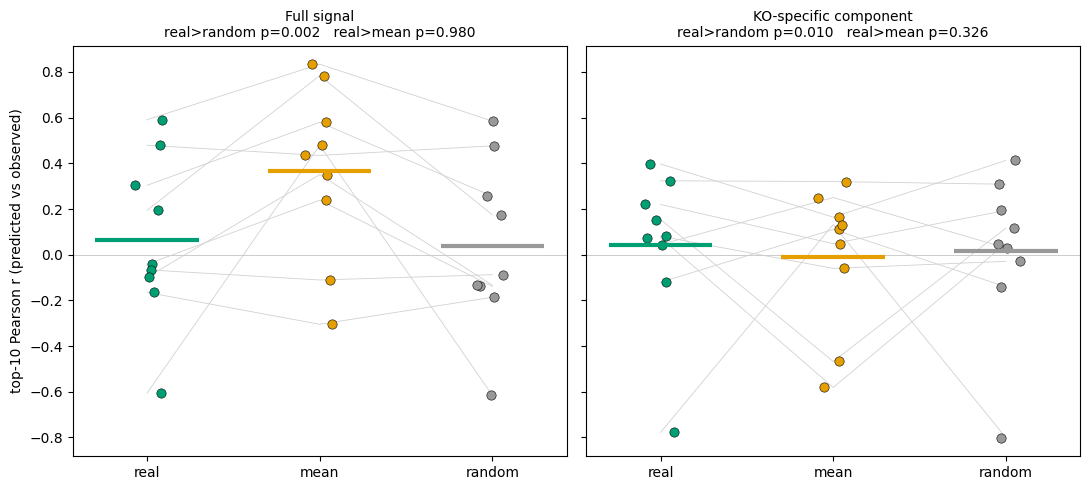

full        : real=0.066  mean=0.365  random=0.037
KO-specific : real=0.044  mean=-0.009  random=0.016


In [29]:
def scores(resid, N=10, EFF=EFF):
    tg = {k: (OBS[k]-shared if resid else OBS[k]) for k in EFF}
    re = [rN(tg[k], REAL5[k], N) for k in EFF]
    ra = [np.mean([rN(tg[k], rp, N) for rp in rand]) for k in EFF]
    me = [rN(tg[k], mean_shift, N) for k in EFF]
    return np.array(re), np.array(ra), np.array(me)

C = {"real":"#009E73","mean":"#E69F00","random":"#999999"}
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for a,(resid,ttl) in zip(ax, [(False,"Full signal"),(True,"KO-specific component")]):
    re,ra,me = scores(resid, EFF=EFF9_2)
    print(re)
    for j,(v,name) in enumerate([(re,"real"),(me,"mean"),(ra,"random")]):
        a.scatter(np.full(len(v),j)+rng.uniform(-.09,.09,len(v)), v, s=45,
                  color=C[name], edgecolor="k", lw=.4, zorder=3)
        a.hlines(v.mean(), j-.3, j+.3, color=C[name], lw=3, zorder=4)
    for k in range(len(EFF9_2)): a.plot([0,1,2],[re[k],me[k],ra[k]], color="0.82", lw=.6, zorder=1)
    a.axhline(0,color="0.8",lw=.7); a.set_xticks([0,1,2]); a.set_xticklabels(["real","mean","random"])
    pr=wilcoxon(re,ra,alternative="greater").pvalue; pm=wilcoxon(re,me,alternative="greater").pvalue
    a.set_title(f"{ttl}\nreal>random p={pr:.3f}   real>mean p={pm:.3f}", fontsize=10)
ax[0].set_ylabel("top-10 Pearson r (predicted vs observed)")
plt.tight_layout(); plt.show()
for resid,ttl in [(False,"full"),(True,"KO-specific")]:
    re,ra,me = scores(resid, EFF=EFF9_2); print(f"{ttl:12s}: real={re.mean():.3f}  mean={me.mean():.3f}  random={ra.mean():.3f}")


In [ ]:
import sys

sys.path.append('../../scripts')

from scipy.stats import spearmanr
from counterfactual_analysis import compute_edistance, direction_match, compute_mse_lfc

n_deg = 10
counts_per_k = 1e4

def _metrics_row(k, lfc_pred, lfc_observed, predicted_expr):
    deg = np.argsort(-np.abs(lfc_observed))[:n_deg]  # rank by the target actually being scored
    #spear, _ = spearmanr(lfc_observed[deg], lfc_pred[deg])
    pear, _ = pearsonr(lfc_observed[deg], lfc_pred[deg])
    dir_match_k = direction_match(lfc_observed[deg], lfc_pred[deg], k=n_deg, normalize="k")
    mse_lfc = compute_mse_lfc(gt_vec=lfc_observed, cf_vec=lfc_pred, deg=deg)
    rmse_lfc = np.sqrt(mse_lfc)
    edist_pca_log = compute_edistance(adata, observed=recon, predicted=predicted_expr, deg=None,
                                       library_size=counts_per_k, local=True, use_pca=True)
    return {"Pearson": pear, "Precision": dir_match_k,
            "E-distance": edist_pca_log, "RMSE_LFC": rmse_lfc}

# Per-cell counterfactual for the mean-shift baseline: apply the (KO-agnostic) mean_shift
# log-fold-change to each real far cell's own baseline expression -- inverting lfc(a,b) =
# log(a+1)-log(b+1) the same way it was built, so it lands on the same 1e4-normalized scale
# as COUNTERFACTUALS/CF_RANDOM and can be fed into compute_edistance the same way.
CF_MEAN = np.clip((recon + 1) * np.exp(mean_shift)[None, :] - 1, 0, None)


In [ ]:
full_results = [{"KO": k, **_metrics_row(k, REAL5[k], OBS[k], COUNTERFACTUALS[k])} for k in EFF9_2]
df_results = pd.DataFrame(full_results)
df_results["type"] = "full"
df_results["baseline"] = f"Cellina-{VARIANT}"
df_results


In [ ]:
ko_results = [{"KO": k, **_metrics_row(k, REAL5[k], OBS[k] - shared, COUNTERFACTUALS[k])} for k in EFF9_2]
ko_results = pd.DataFrame(ko_results)
ko_results["type"] = "KO-specific"
ko_results["baseline"] = f"Cellina-{VARIANT}"
df_results = pd.concat([df_results, ko_results], ignore_index=True)
df_results


In [ ]:
# mean-shift baseline: same predicted vector (and same CF_MEAN matrix) for every KO.
mean_results = []
for k in EFF9_2:
    mean_results.append({"KO": k, "type": "full", "baseline": "mean",
                          **_metrics_row(k, mean_shift, OBS[k], CF_MEAN)})
    mean_results.append({"KO": k, "type": "KO-specific", "baseline": "mean",
                          **_metrics_row(k, mean_shift, OBS[k] - shared, CF_MEAN)})
df_results = pd.concat([df_results, pd.DataFrame(mean_results)], ignore_index=True)
df_results


In [ ]:
# random-insertion baseline: average each metric across the 5 draws (same convention
# scores() uses for the Pearson correlation itself), so this stays comparable to §4.3.
random_results = []
for k in EFF9_2:
    full_draws = pd.DataFrame([_metrics_row(k, rand[i], OBS[k], CF_RANDOM[i]) for i in range(len(rand))])
    ko_draws = pd.DataFrame([_metrics_row(k, rand[i], OBS[k] - shared, CF_RANDOM[i]) for i in range(len(rand))])
    random_results.append({"KO": k, "type": "full", "baseline": f"Cellina-{VARIANT}-random", **full_draws.mean().to_dict()})
    random_results.append({"KO": k, "type": "KO-specific", "baseline": f"Cellina-{VARIANT}-random", **ko_draws.mean().to_dict()})
df_results = pd.concat([df_results, pd.DataFrame(random_results)], ignore_index=True)
df_results


In [ ]:
metrics = ['Pearson', 'Precision', 'E-distance', 'RMSE_LFC']

summary = df_results.groupby(['type', 'baseline'])[metrics].agg(['mean', 'std'])

# Nicely formatted mean±std strings
summary_fmt = df_results.groupby(['type', 'baseline'])[metrics].agg(lambda x: f"{x.mean():.2f} ± {x.std():.2f}")
summary_fmt


In [ ]:
# Write to disk -- distinct filename from pfish_analysis.ipynb's node-perturbation run
# (../../results/invivo_{VARIANT}.csv), so the two counterfactual mechanisms stay
# side by side instead of one silently overwriting the other.
df_results.to_csv(f"../../results/invivo_{VARIANT}_edgepert.csv")


### 4.4 Strong-gene robustness

The 154-gene panel is mostly flat (median gene |lnFC|≈0.13); the signal lives in a thin tail of
responders. Sweeping the number of strongest genes shows real insertions separate from the mean
baseline on the top responders, while random stays at zero.


In [ ]:
Ns=[10,20,30,40,50,154]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a,(resid,ttl) in zip(ax, [(False,"Full signal"),(True,"KO-specific component")]):
    for name in ["real","mean","random"]:
        ys=[]
        for N in Ns:
            re,ra,me = scores(resid, N)
            ys.append({"real":re,"mean":me,"random":ra}[name].mean())
        a.plot(Ns, ys, "-o", color=C[name], lw=2, ms=5, label=name)
    a.axvline(10,color="k",ls=":",lw=.9); a.axhline(0,color="0.8",lw=.7)
    a.set_xlabel("# strongest genes (top-N)"); a.set_title(ttl, fontsize=10)
ax[0].set_ylabel("Pearson r (mean of 9 KOs)"); ax[0].legend(frameon=False)
plt.tight_layout(); plt.show()


### 4.5 Dose-response

More perturbed cancer cells in a T cell's neighbourhood → a stronger observed shift. This is the
clearest confirmation the effect is genuinely driven by the perturbed neighbours. (This section is
purely descriptive of the real, observed data -- no model counterfactual involved -- so it is
unaffected by the edge- vs node-perturbation switch.)


In [ ]:
DOSES=[("1",lambda d:d==1),("2",lambda d:d==2),("3",lambda d:d==3),("4+",lambda d:d>=4)]; X={"1":1,"2":2,"3":3,"4+":4}
rec=[]
for ko in EFF:
    npk=np.asarray(Abin.dot((pc&(pert==ko)).astype(float))).ravel()
    noth=np.asarray(conn.dot((pc&(pert!=ko)).astype(float))).ravel()>0
    for lab,f in DOSES:
        t=np.where(uT&f(npk)&~noth)[0]
        if len(t)<15: continue
        ob=lfc(pn(t),pn(match(t,far))); rec.append(dict(x=X[lab],n=len(t),mag=np.abs(ob)[np.argsort(-np.abs(ob))[:10]].mean()))
dd=pd.DataFrame(rec); g=dd.groupby("x").agg(m=("mag","mean"),se=("mag",lambda v:v.std()/max(1,np.sqrt(len(v)))),n=("n","sum"))
plt.figure(figsize=(5,4.5))
plt.errorbar(g.index,g.m,yerr=g.se,fmt="-o",color="#333",lw=2,ms=8,capsize=4)
for x,r in g.iterrows(): plt.annotate(f"n={int(r.n)}",(x,r.m),textcoords="offset points",xytext=(8,8),fontsize=8,color="0.4")
plt.xticks([1,2,3,4],["1","2","3","4+"]); plt.xlabel("# perturbed neighbours (dose)")
plt.ylabel("observed top-10 mean |lnFC|"); plt.title("Observed effect vs dose"); plt.tight_layout(); plt.show()


### 4.6 Why insertion, and not the environment swap?

One other edge-rewiring counterfactual worth trying, and why it should fail:
- **ground-truth environment** — rewire `far` onto the *real* neighbours of the actual near-KO-T
  cells (a realistic, mostly non-perturbed niche), instead of onto 100% real KO'd-cancer donors.

That real niche is ~94% non-perturbed, so the KO signal should be diluted out. On the KO-specific
component we expect this to give ≈0, while the saturated insertion (100% perturbed-cancer donors)
retains the signal.


In [ ]:
gte = {}
for ko in EFF:
    kc = pc & (pert==ko); near=np.asarray(conn.dot(kc.astype(float))).ravel()>0
    noth=np.asarray(conn.dot((pc&(pert!=ko)).astype(float))).ravel()>0
    t=np.where(uT&near&~noth)[0]
    # ground-truth environment: rewire `far` onto the REAL neighbours of the actual
    # near-KO-T cells -- same edge-rewiring mechanism as §4.2, only the donor pool
    # changes (realistic mixed niche vs. 100% KO-cancer donors). Excludes T-cell
    # neighbours, mirroring pfish_prep.make_edge_swap_sets' donor_idx convention.
    env_pool = np.unique(conn[t].nonzero()[1])
    env_pool = env_pool[~is_T[env_pool]]
    gte[ko] = insert(env_pool)[0]
res_real=[rN(OBS[k]-shared, REAL[k]) for k in EFF]
res_gte =[rN(OBS[k]-shared, gte[k]) for k in EFF]
print(f"KO-specific r  |  insertion (100% KO donors) = {np.mean(res_real):.3f}   ground-truth env (real niche donors) = {np.mean(res_gte):.3f}")
print(f"real > ground-truth-env  paired p = {wilcoxon(res_real,res_gte,alternative='greater').pvalue:.3f}")


## 5. Interpretation

This mirrors `pfish_analysis.ipynb`'s analysis, except §4.2/§4.6 now use Cellina's true
edge-perturbation API (`get_counterfactual_expression`/`get_counterfactual_latents`) instead of node
perturbation: a far T cell's *neighbours* are genuinely rewired to real donor cells, rather than
having a synthetic signature written into its own niche features/layer. Re-run this notebook to get
results under the corrected mechanism, then compare against `pfish_analysis.ipynb`'s
`results/invivo_{VARIANT}.csv` side by side with this notebook's
`results/invivo_{VARIANT}_edgepert.csv`.

Expected qualitative story, to be confirmed by re-running:
- **Perturbations act cell-intrinsically** — 9/35 KOs have a real direct effect on their own cancer
  cell; the rest cannot propagate anything (unaffected by §4.2's mechanism, computed in §4.1).
- **Real ≫ random**: the KO *identity* of the rewired donor cells matters.
- **Real ≫ mean on the KO-specific component**: once the shared tumour-region confound is removed,
  the mean baseline should collapse to ~0 while real edge-rewired insertions retain a genuine,
  perturbation-specific signal.
- **Dose-response**: the observed effect grows monotonically with the number of perturbed neighbours
  (real data, unaffected by §4.2's mechanism).
- **Insertion, not swap**: only rewiring onto 100% real KO donors should carry the signal; rewiring
  onto the real (diluted, ~94% non-perturbed) niche should not.
